In [133]:
import pyarrow.dataset as ds
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [134]:
path = r"d:\PredectiveIntelligenceSystem\report_spark\curated_usage"

In [135]:
dataset = ds.dataset(
    path,
    format="parquet",
    partitioning="hive"  # reads date=YYYY-MM-DD partitions
)

table = dataset.to_table()
df = table.to_pandas()

In [136]:
df.head()

,timestamp,grid_id,country_code,sms_in_count,sms_out_count,call_in_count,call_out_count,internet_usage,input_file_name,hour,day_of_week,total_sms,total_calls,total_activity,date
0,2013-10-31 18:30:00,1,0,0.3521,0.0000,0.0000,0.0273,0.0000,file:///D:/PredectiveIntelligenceSystem/data/s...,0,6,0.3521,0.0273,0.3794,2013-11-01
1,2013-10-31 18:30:00,1,33,0.0000,0.0000,0.0000,0.0000,0.0261,file:///D:/PredectiveIntelligenceSystem/data/s...,0,6,0.0000,0.0000,0.0261,2013-11-01
2,2013-10-31 18:30:00,1,39,1.7322,1.1047,0.5919,0.4020,57.7729,file:///D:/PredectiveIntelligenceSystem/data/s...,0,6,2.8369,0.9939,61.6037,2013-11-01
3,2013-10-31 18:30:00,2,0,0.3581,0.0000,0.0000,0.0273,0.0000,file:///D:/PredectiveIntelligenceSystem/data/s...,0,6,0.3581,0.0273,0.3854,2013-11-01
4,2013-10-31 18:30:00,2,33,0.0000,0.0000,0.0000,0.0000,0.0274,file:///D:/PredectiveIntelligenceSystem/data/s...,0,6,0.0000,0.0000,0.0274,2013-11-01


In [137]:
df.shape

(15089165, 15)

In [138]:
df["grid_id"] = df["grid_id"].astype(int)

In [139]:
df.describe()

,timestamp,grid_id,sms_in_count,sms_out_count,call_in_count,call_out_count,internet_usage,hour,day_of_week,total_sms,total_calls,total_activity
count,15089165,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07
mean,2013-11-04 12:46:57.749360128,5.304882e+03,3.015470e+00,1.703600e+00,2.001247e+00,2.295141e+00,4.557019e+01,1.310435e+01,3.950441e+00,4.719070e+00,4.296389e+00,5.458564e+01
min,2013-10-31 18:30:00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2013-11-02 18:30:00,3.162000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,5.690000e-02
50%,2013-11-04 14:30:00,5.442000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,4.000000e+00,0.000000e+00,1.000000e-02,2.041000e-01
75%,2013-11-06 06:30:00,7.539000e+03,2.493000e-01,0.000000e+00,1.010000e-02,1.399000e-01,1.516000e-01,1.800000e+01,5.000000e+00,3.808000e-01,2.313000e-01,1.102100e+00
max,2013-11-07 17:30:00,1.000000e+04,2.288739e+03,2.270682e+03,1.328088e+03,1.511686e+03,3.174863e+04,2.300000e+01,7.000000e+00,4.503561e+03,2.797349e+03,3.564692e+04
std,NaN,2.722514e+03,1.712616e+01,1.222340e+01,1.530519e+01,1.678532e+01,2.845900e+02,5.877285e+00,1.902451e+00,2.829099e+01,3.195753e+01,3.384177e+02


In [140]:
df.columns

Index(['timestamp', 'grid_id', 'country_code', 'sms_in_count', 'sms_out_count',
       'call_in_count', 'call_out_count', 'internet_usage', 'input_file_name',
       'hour', 'day_of_week', 'total_sms', 'total_calls', 'total_activity',
       'date'],
      dtype='str')

In [141]:
# df["target_high_activity"] = df_agg["target_high_activity"]

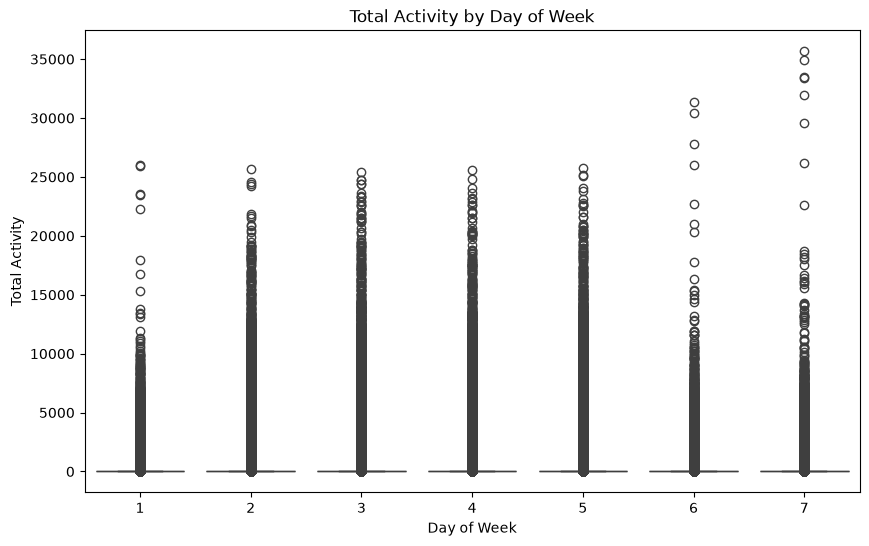

In [142]:
day_order = [1, 2, 3, 4, 5, 6, 7]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="day_of_week",
    y="total_activity",
    order=day_order
)

plt.title("Total Activity by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Activity")

plt.show()

In [143]:
df_grouped = (
    df.groupby(['timestamp', 'grid_id'], as_index=False)
      .sum(numeric_only=True)
)

In [144]:
# df_grouped.drop(columns = ["target_high_activity"], inplace = True)

In [145]:
df_grouped.shape

(1679994, 12)

In [146]:
from scipy.stats import f_oneway

groups = [
    df_grouped[df_grouped["grid_id"] == d]["total_activity"]
    for d in sorted(df["grid_id"].unique())
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)


F-statistic: 353.0202678536216
P-value: 0.0


In [147]:
from scipy.stats import f_oneway

groups = [
    df[df["day_of_week"] == d]["total_activity"]
    for d in sorted(df["day_of_week"].unique())
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)


F-statistic: 136.75293618264485
P-value: 5.739359187580927e-174


In [148]:
from scipy.stats import f_oneway

groups = [
    df[df["hour"] == h]["total_activity"]
    for h in sorted(df["hour"].unique())
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 213.21839238158057
P-value: 0.0


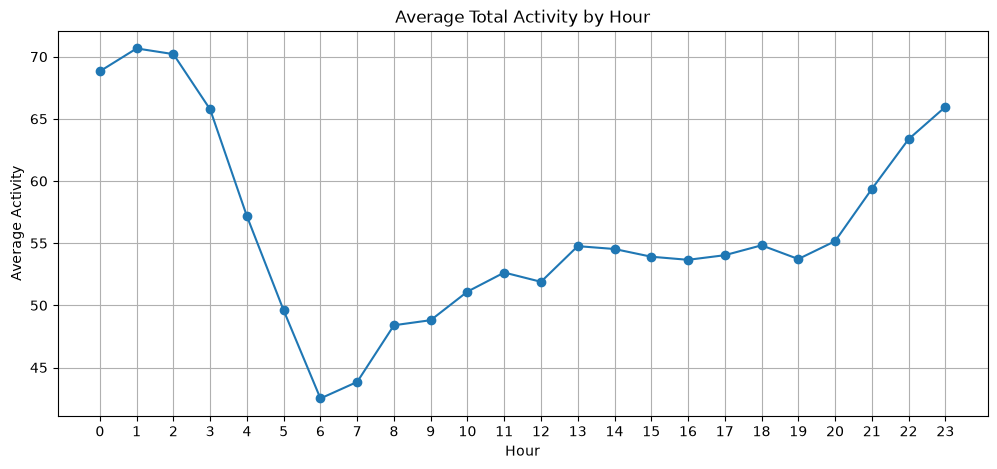

In [149]:


hourly_avg = df.groupby("hour")["total_activity"].mean()

plt.figure(figsize=(12,5))
hourly_avg.plot(marker='o')

plt.title("Average Total Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Activity")
plt.xticks(range(24))
plt.grid(True)
plt.show()

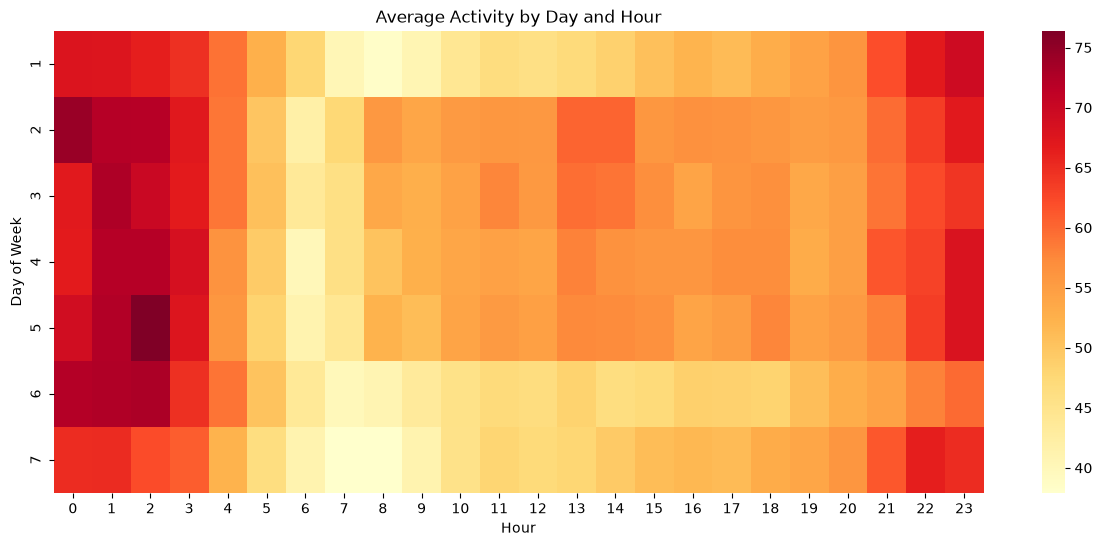

In [150]:

pivot = df.pivot_table(
    values="total_activity",
    index="day_of_week",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(15,6))
sns.heatmap(pivot, cmap="YlOrRd")

plt.title("Average Activity by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

In [151]:
df = df.drop(columns=["input_file_name"])

In [152]:
df["timestamp"].nunique()

168

In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15089165 entries, 0 to 15089164
Data columns (total 14 columns):
 #   Column          Dtype         
---  ------          -----         
 0   timestamp       datetime64[ns]
 1   grid_id         int64         
 2   country_code    str           
 3   sms_in_count    float64       
 4   sms_out_count   float64       
 5   call_in_count   float64       
 6   call_out_count  float64       
 7   internet_usage  float64       
 8   hour            int32         
 9   day_of_week     int32         
 10  total_sms       float64       
 11  total_calls     float64       
 12  total_activity  float64       
 13  date            str           
dtypes: datetime64[ns](1), float64(8), int32(2), int64(1), str(2)
memory usage: 1.6 GB


In [154]:
import numpy as np
import pandas as pd


In [155]:
agg_dict = {
        "total_activity": "sum",
        "internet_usage": "sum",
        "total_sms": "sum",
        "total_calls": "sum",
        "sms_in_count": "sum",
        "sms_out_count": "sum",
        "call_in_count": "sum",
        "call_out_count": "sum"
    }

In [156]:
df_agg = (
        df.groupby(["grid_id", "timestamp"], as_index=False)
        .agg(agg_dict)
        .sort_values(["grid_id", "timestamp"])
        .reset_index(drop=True)
    )

In [157]:
df_agg.head()

,grid_id,timestamp,total_activity,internet_usage,total_sms,total_calls,sms_in_count,sms_out_count,call_in_count,call_out_count
0,1,2013-10-31 18:30:00,62.0092,57.7990,3.1890,1.0212,2.0843,1.1047,0.5919,0.4293
1,1,2013-10-31 19:30:00,46.3654,44.0469,1.9337,0.3848,1.1637,0.7700,0.1906,0.1942
2,1,2013-10-31 20:30:00,42.0870,41.2071,0.7160,0.1639,0.4156,0.3004,0.0279,0.1360
3,1,2013-10-31 21:30:00,35.0978,33.0221,2.0478,0.0279,1.1521,0.8957,0.0018,0.0261
4,1,2013-10-31 22:30:00,32.2741,31.3769,0.8657,0.0315,0.3545,0.5112,0.0054,0.0261


In [158]:
grid_group = df_agg.groupby("grid_id")
grid_group

In [159]:
df_agg["baseline_24h"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(24, min_periods=6).median()
    )

In [160]:
df_agg.head(10)

,grid_id,timestamp,total_activity,internet_usage,total_sms,total_calls,sms_in_count,sms_out_count,call_in_count,call_out_count,baseline_24h
0,1,2013-10-31 18:30:00,62.0092,57.7990,3.1890,1.0212,2.0843,1.1047,0.5919,0.4293,NaN
1,1,2013-10-31 19:30:00,46.3654,44.0469,1.9337,0.3848,1.1637,0.7700,0.1906,0.1942,NaN
2,1,2013-10-31 20:30:00,42.0870,41.2071,0.7160,0.1639,0.4156,0.3004,0.0279,0.1360,NaN
3,1,2013-10-31 21:30:00,35.0978,33.0221,2.0478,0.0279,1.1521,0.8957,0.0018,0.0261,NaN
4,1,2013-10-31 22:30:00,32.2741,31.3769,0.8657,0.0315,0.3545,0.5112,0.0054,0.0261,NaN
5,1,2013-10-31 23:30:00,35.4160,34.8416,0.3623,0.2121,0.1669,0.1954,0.0279,0.1842,38.7515
6,1,2013-11-01 00:30:00,36.1216,35.4161,0.3308,0.3747,0.2150,0.1158,0.2168,0.1579,36.1216
7,1,2013-11-01 01:30:00,44.7950,42.9335,1.1234,0.7381,0.8787,0.2447,0.2435,0.4946,39.1043
8,1,2013-11-01 02:30:00,67.4200,59.8808,5.1015,2.4377,3.6649,1.4366,1.1609,1.2768,42.0870
9,1,2013-11-01 03:30:00,83.7437,71.1355,6.4750,6.1332,4.3597,2.1153,2.9113,3.2219,43.4410


In [215]:
df_agg["future_activity_t1"] = grid_group["total_activity"].shift(-1)
df_agg["future_baseline_t1"] = grid_group["baseline_24h"].shift(-1)

In [216]:
valid_target = df_agg["future_activity_t1"].notna() & (df_agg["future_baseline_t1"] > 0)

df_agg["target_high_activity"] = 0

df_agg.loc[ valid_target & (df_agg["future_activity_t1"] >= df_agg["future_baseline_t1"]*1.4), "target_high_activity"] =1

In [ ]:
df_agg["target_high_activity"].value_counts()

target_high_activity
0    1206395
1     223599
Name: count, dtype: int64

In [ ]:
df_agg["target_high_activity"].value_counts()

target_high_activity
0    1426845
1     253149
Name: count, dtype: int64

In [195]:
lent = df_agg["target_high_activity"].value_counts().sum()
print((188349/lent)*100)
print((253149/lent)*100)

13.17131400551331
17.702801550216293


In [193]:
# df_agg[(df_agg["target_high_activity"] == 1) & (df_agg["grid_id"]==2)]

In [167]:
df_agg["feature_timestamp"] = df_agg["timestamp"]

In [168]:
df_agg["avg_activity_6h"] = grid_group["total_activity"].transform(
    lambda s: s.rolling(6, min_periods=1).mean())

df_agg["prior_baseline_24h"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(24, min_periods=1).mean()  )

In [169]:
eps = 1e-6

In [170]:
df_agg["activity_growth"] = (df_agg["avg_activity_6h"] + eps) / (
        df_agg["prior_baseline_24h"] + eps
    )

In [171]:
df_agg["active_hours"] = grid_group["total_activity"].transform(
        lambda s: (s > 0).rolling(6, min_periods=1).sum())

In [172]:
df_agg["peak_activity"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(6, min_periods=1).max())

In [173]:
df_agg["peak_ratio"] = (df_agg["peak_activity"] + eps) / (
        df_agg["avg_activity_6h"] + eps
    )

In [174]:
roll_std = grid_group["total_activity"].transform(
        lambda s: s.rolling(6, min_periods=1).std().fillna(0))
    
df_agg["variability"] = roll_std / (df_agg["avg_activity_6h"] + eps)

In [175]:
df_agg["current_to_baseline_ratio"] = (df_agg["total_activity"] + eps) / (
        df_agg["baseline_24h"] + eps
    )

In [176]:
# 3. Lags & Momentum

df_agg["activity_lag_1h"] = grid_group["total_activity"].shift(1)
df_agg["activity_lag_2h"] = grid_group["total_activity"].shift(2)
df_agg["activity_lag_24h"] = grid_group["total_activity"].shift(24)


df_agg["velocity_1h"] = df_agg["total_activity"] - df_agg["activity_lag_1h"]
df_agg["acceleration_1h"] = (
        df_agg["total_activity"]
        - 2 * df_agg["activity_lag_1h"]
        + df_agg["activity_lag_2h"]
    )
df_agg["activity_vs_same_hour_yesterday"] = (df_agg["total_activity"] + eps) / (
        df_agg["activity_lag_24h"] + eps
    )

In [177]:
# 4. Traffic Composition
roll_internet = grid_group["internet_usage"].transform(
    lambda s: s.rolling(6, min_periods=1).sum()
)
roll_total = grid_group["total_activity"].transform(
    lambda s: s.rolling(6, min_periods=1).sum()
)
df_agg["internet_share"] = (roll_internet + eps) / (roll_total + eps)
df_agg["sms_to_call_ratio"] = (df_agg["total_sms"] + eps) / (
    df_agg["total_calls"] + eps
)

In [178]:
# 5. Temporal Features
hour = df_agg["feature_timestamp"].dt.hour
dow = df_agg["feature_timestamp"].dt.dayofweek
df_agg["hour"] = hour
df_agg["day_of_week"] = dow
df_agg["is_weekend"] = dow.isin([5, 6]).astype(int)
df_agg["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
df_agg["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
df_agg["dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
df_agg["dow_cos"] = np.cos(2 * np.pi * dow / 7.0)

In [179]:
# df_agg["grid_id"] = df_agg["grid_id"].astype("category")
df_agg.drop(columns=["grid_id","active_hours"], inplace = True)

In [180]:
df_agg.shape

(1679994, 36)

In [181]:
df_agg["target_high_activity"].value_counts()

target_high_activity
0    1426845
1     253149
Name: count, dtype: int64

In [182]:
df_agg.info()

<class 'pandas.DataFrame'>
RangeIndex: 1679994 entries, 0 to 1679993
Data columns (total 36 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   timestamp                        1679994 non-null  datetime64[ns]
 1   total_activity                   1679994 non-null  float64       
 2   internet_usage                   1679994 non-null  float64       
 3   total_sms                        1679994 non-null  float64       
 4   total_calls                      1679994 non-null  float64       
 5   sms_in_count                     1679994 non-null  float64       
 6   sms_out_count                    1679994 non-null  float64       
 7   call_in_count                    1679994 non-null  float64       
 8   call_out_count                   1679994 non-null  float64       
 9   baseline_24h                     1629994 non-null  float64       
 10  future_activity_t1               1669994 

In [183]:
df_agg.head(10)

,timestamp,total_activity,internet_usage,total_sms,total_calls,sms_in_count,sms_out_count,call_in_count,call_out_count,baseline_24h,...,activity_vs_same_hour_yesterday,internet_share,sms_to_call_ratio,hour,day_of_week,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos
0,2013-10-31 18:30:00,62.0092,57.7990,3.1890,1.0212,2.0843,1.1047,0.5919,0.4293,NaN,...,NaN,0.932104,3.122795,18,3,0,-1.000000,-1.836970e-16,0.433884,-0.900969
1,2013-10-31 19:30:00,46.3654,44.0469,1.9337,0.3848,1.1637,0.7700,0.1906,0.1942,NaN,...,NaN,0.939758,5.025197,19,3,0,-0.965926,2.588190e-01,0.433884,-0.900969
2,2013-10-31 20:30:00,42.0870,41.2071,0.7160,0.1639,0.4156,0.3004,0.0279,0.1360,NaN,...,NaN,0.950761,4.368497,20,3,0,-0.866025,5.000000e-01,0.433884,-0.900969
3,2013-10-31 21:30:00,35.0978,33.0221,2.0478,0.0279,1.1521,0.8957,0.0018,0.0261,NaN,...,NaN,0.948888,73.395255,21,3,0,-0.707107,7.071068e-01,0.433884,-0.900969
4,2013-10-31 22:30:00,32.2741,31.3769,0.8657,0.0315,0.3545,0.5112,0.0054,0.0261,NaN,...,NaN,0.952342,27.481699,22,3,0,-0.500000,8.660254e-01,0.433884,-0.900969
5,2013-10-31 23:30:00,35.4160,34.8416,0.3623,0.2121,0.1669,0.1954,0.0279,0.1842,38.7515,...,NaN,0.956739,1.708153,23,3,0,-0.258819,9.659258e-01,0.433884,-0.900969
6,2013-11-01 00:30:00,36.1216,35.4161,0.3308,0.3747,0.2150,0.1158,0.2168,0.1579,36.1216,...,NaN,0.967228,0.882840,0,4,0,0.000000,1.000000e+00,-0.433884,-0.900969
7,2013-11-01 01:30:00,44.7950,42.9335,1.1234,0.7381,0.8787,0.2447,0.2435,0.4946,39.1043,...,NaN,0.969024,1.522015,1,4,0,0.258819,9.659258e-01,-0.433884,-0.900969
8,2013-11-01 02:30:00,67.4200,59.8808,5.1015,2.4377,3.6649,1.4366,1.1609,1.2768,42.0870,...,NaN,0.945631,2.092751,2,4,0,0.500000,8.660254e-01,-0.433884,-0.900969
9,2013-11-01 03:30:00,83.7437,71.1355,6.4750,6.1332,4.3597,2.1153,2.9113,3.2219,43.4410,...,NaN,0.919318,1.055729,3,4,0,0.707107,7.071068e-01,-0.433884,-0.900969


In [184]:

df_agg["activity_vs_same_hour_yesterday"].iloc[23]

np.float64(nan)

In [185]:
df_agg = df_agg.dropna().reset_index(drop=True)

<h1>Training Phase</h1>

In [186]:
import lightgbm as lgb

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
)

In [192]:
print(type(len))
print(len)

<class 'numpy.int64'>
1679994


In [129]:
train_ratio = 0.8

In [197]:
df_agg = df_agg.sort_values("feature_timestamp").reset_index(drop=True)

split_idx = int(len(df_agg)*train_ratio)
train_df = df_agg.iloc[:split_idx]
test_df = df_agg.iloc[split_idx:]

In [198]:
features = [
        "activity_growth",
        "variability",
        "peak_ratio",
        "internet_share",
        "avg_activity_6h",
        "current_to_baseline_ratio",
        "velocity_1h",
        "acceleration_1h",
        "activity_vs_same_hour_yesterday",
        "sms_to_call_ratio",
        "hour",
        "day_of_week",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
    ]

In [ ]:

# from sklearn.model_selection import train_test_split

# train_df, test_df = train_test_split(
#     df_agg,
#     test_size=1 - train_ratio,
#     random_state=42,
#     stratify=df_agg["target_high_activity"],
# )

# X_train = train_df[features]
# y_train = train_df["target_high_activity"]

# X_test = test_df[features]
# y_test = test_df["target_high_activity"]

# print(f"Train shape: {train_df.shape}")
# print(f"Test shape:  {test_df.shape}")
# print(f"Train positive rate: {y_train.mean():.4%}")
# print(f"Test positive rate:  {y_test.mean():.4%}")

Train shape: (1343995, 38)
Test shape:  (335999, 38)
Train positive rate: 11.2113%
Test positive rate:  11.2113%


In [199]:
X_train, y_train = train_df[features], train_df["target_high_activity"]
X_test, y_test = test_df[features], test_df["target_high_activity"]

In [200]:
pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())

In [201]:
model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.015,  # Lower learning rate + more trees yields better generalization
        num_leaves=127,  # Allows deeper feature interactions
        max_depth=9,
        min_child_samples=50,  # Prevents overfitting on rare grid IDs
        subsample=0.7,  # Row bagging
        subsample_freq=1,
        colsample_bytree=0.7,  # Feature bagging
        scale_pos_weight=pos_weight
        * 0.7,  # Slightly downscale weight to boost precision
        force_col_wise=True,
        random_state=42,
        n_jobs=-1,
    )

In [202]:
model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
    )


c:\Users\chandru.sivakumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 153805, number of negative: 990190
[LightGBM] [Info] Total Bins 2634
[LightGBM] [Info] Number of data points in the train set: 1143995, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134446 -> initscore=-1.862211
[LightGBM] [Info] Start training from score -1.862211


,num_leaves,127
,max_depth,9
,learning_rate,0.015
,n_estimators,1000
,min_child_samples,50
,subsample,0.7
,subsample_freq,1
,colsample_bytree,0.7
,random_state,42
,n_jobs,-1
,scale_pos_weight,np.float64(4.506570007477)


In [206]:
y_proba = model.predict_proba(X_test)[:, 1]

In [207]:
# Metrics
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = (
    2
    * (precisions * recalls)
    / np.clip(precisions + recalls, 1e-6, None)
)
best_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[best_idx]

In [208]:
print(f"\nOptimal F1 Threshold ({optimal_threshold:.4f}) Report:")

print(
        classification_report(
            y_test,
            (y_proba >= optimal_threshold).astype(int),
            digits=4,
            zero_division=0,
        )
    )
print("roc_auc : ",roc_auc)
print("pr_auc : ",pr_auc)


Optimal F1 Threshold (0.7143) Report:
              precision    recall  f1-score   support

           0     0.9681    0.9711    0.9696    255776
           1     0.7490    0.7289    0.7389     30223

    accuracy                         0.9455    285999
   macro avg     0.8586    0.8500    0.8542    285999
weighted avg     0.9449    0.9455    0.9452    285999

roc_auc :  0.9650012482254857
pr_auc :  0.8262748670726029


In [61]:
print("\nDefault Threshold (0.50) Report:")
print( classification_report(
            y_test, (y_proba >= 0.50).astype(int), digits=4, zero_division=0
        )
)


Default Threshold (0.50) Report:
              precision    recall  f1-score   support

           0     0.9874    0.9474    0.9670    265154
           1     0.5587    0.8464    0.6731     20845

    accuracy                         0.9401    285999
   macro avg     0.7730    0.8969    0.8201    285999
weighted avg     0.9562    0.9401    0.9456    285999



In [ ]:
print("\nDefault Threshold (0.50) Report:")
print( classification_report(
            y_test, (y_proba >= 0.50).astype(int), digits=4, zero_division=0
        )
)


Default Threshold (0.50) Report:
              precision    recall  f1-score   support

           0     0.9831    0.9446    0.9635    308216
           1     0.5715    0.8202    0.6737     27783

    accuracy                         0.9343    335999
   macro avg     0.7773    0.8824    0.8186    335999
weighted avg     0.9491    0.9343    0.9395    335999



In [44]:
print("\nDefault Threshold (0.50) Report:")
print( classification_report(
            y_test, (y_proba >= 0.50).astype(int), digits=4, zero_division=0
        )
)


Default Threshold (0.50) Report:
              precision    recall  f1-score   support

           0     0.9861    0.9386    0.9617    298329
           1     0.6478    0.8949    0.7516     37670

    accuracy                         0.9337    335999
   macro avg     0.8169    0.9167    0.8567    335999
weighted avg     0.9481    0.9337    0.9382    335999



In [67]:
from sklearn.metrics import roc_auc_score, average_precision_score

In [68]:
y_prob = model.predict_proba(X_test)[:, 1]

In [69]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC : {pr_auc:.4f}")

ROC-AUC: 0.9714
PR-AUC : 0.8143


In [62]:
print(f"\nOptimal F1 Threshold ({optimal_threshold:.4f}) Report:")

print(
        classification_report(
            y_test,
            (y_proba >= optimal_threshold).astype(int),
            digits=4,
            zero_division=0,
        )
    )


Optimal F1 Threshold (0.7638) Report:
              precision    recall  f1-score   support

           0     0.9775    0.9813    0.9794    265154
           1     0.7501    0.7121    0.7306     20845

    accuracy                         0.9617    285999
   macro avg     0.8638    0.8467    0.8550    285999
weighted avg     0.9609    0.9617    0.9613    285999



In [54]:
print(f"\nOptimal F1 Threshold ({optimal_threshold:.4f}) Report:")

print(
        classification_report(
            y_test,
            (y_proba >= optimal_threshold).astype(int),
            digits=4,
            zero_division=0,
        )
    )


Optimal F1 Threshold (0.6675) Report:
              precision    recall  f1-score   support

           0     0.9733    0.9738    0.9736    308216
           1     0.7077    0.7041    0.7059     27783

    accuracy                         0.9515    335999
   macro avg     0.8405    0.8389    0.8397    335999
weighted avg     0.9514    0.9515    0.9514    335999



In [ ]:
print(f"\nOptimal F1 Threshold ({optimal_threshold:.4f}) Report:")

print(
        classification_report(
            y_test,
            (y_proba >= optimal_threshold).astype(int),
            digits=4,
            zero_division=0,
        )
    )


Optimal F1 Threshold (0.7691) Report:
              precision    recall  f1-score   support

           0     0.9720    0.9779    0.9749    298329
           1     0.8160    0.7772    0.7961     37670

    accuracy                         0.9554    335999
   macro avg     0.8940    0.8776    0.8855    335999
weighted avg     0.9545    0.9554    0.9549    335999



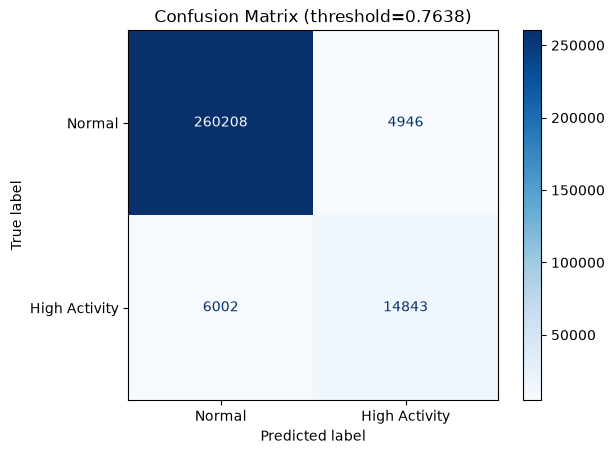

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = (y_proba >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "High Activity"],
).plot(cmap="Blues", values_format="d")

import matplotlib.pyplot as plt
plt.title(f"Confusion Matrix (threshold={optimal_threshold:.4f})")
plt.show()

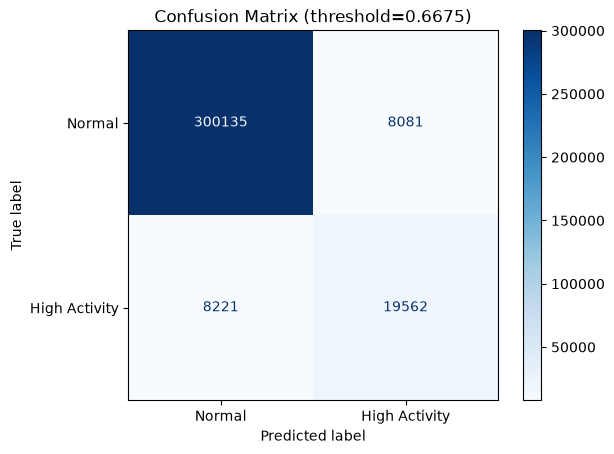

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = (y_proba >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "High Activity"],
).plot(cmap="Blues", values_format="d")

import matplotlib.pyplot as plt
plt.title(f"Confusion Matrix (threshold={optimal_threshold:.4f})")
plt.show()

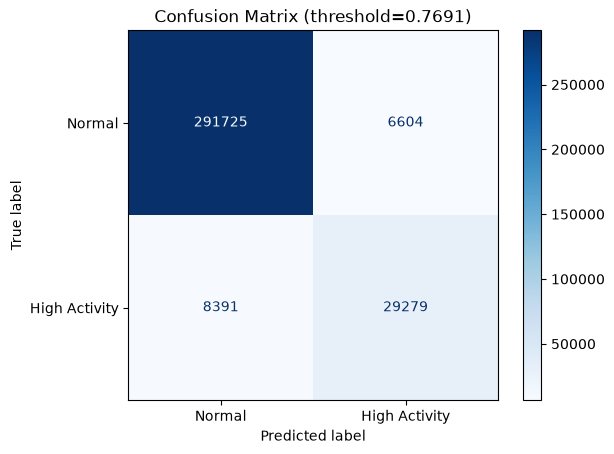

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = (y_proba >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "High Activity"],
).plot(cmap="Blues", values_format="d")

import matplotlib.pyplot as plt
plt.title(f"Confusion Matrix (threshold={optimal_threshold:.4f})")
plt.show()

In [64]:
importances = pd.Series(
        model.feature_importances_, index=features
    ).sort_values(ascending=False)

for feat, imp in importances.items():
        print(f"{feat:<32}: {imp:.4f}")

avg_activity_6h                 : 12648.0000
activity_growth                 : 11889.0000
activity_vs_same_hour_yesterday : 11555.0000
internet_share                  : 10700.0000
current_to_baseline_ratio       : 10355.0000
velocity_1h                     : 9676.0000
sms_to_call_ratio               : 9571.0000
acceleration_1h                 : 9361.0000
variability                     : 8916.0000
peak_ratio                      : 8860.0000
hour                            : 6132.0000
hour_sin                        : 4226.0000
day_of_week                     : 3951.0000
hour_cos                        : 3880.0000
dow_sin                         : 2566.0000
dow_cos                         : 1341.0000
is_weekend                      : 373.0000


In [66]:
from pathlib import Path
import joblib

# 1. Create model registry directory
save_dir = Path("d:/PredectiveIntelligenceSystem/DataAnalysis/models")
save_dir.mkdir(parents=True, exist_ok=True)

# 2. Package all operational artifacts
model_bundle = {
    "model": model,
    "optimal_threshold": float(optimal_threshold),
    "features": features,
    "metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "best_f1": float(f1_scores[best_idx]),
    },
    "high_threshold": 1.5,
}

# 3. Save compressed artifact
artifact_path = save_dir / "lgbm_high_activity_v2.joblib"
joblib.dump(model_bundle, artifact_path, compress=3)
print(f"Artifact bundle saved to: {artifact_path}")

Artifact bundle saved to: d:\PredectiveIntelligenceSystem\DataAnalysis\models\lgbm_high_activity_v2.joblib


In [16]:
raw_test_df = df.copy()

In [17]:
raw_test_df.head()

,timestamp,grid_id,country_code,sms_in_count,sms_out_count,call_in_count,call_out_count,internet_usage,hour,day_of_week,total_sms,total_calls,total_activity,date
0,2013-10-31 18:30:00,1,0,0.3521,0.0000,0.0000,0.0273,0.0000,0,6,0.3521,0.0273,0.3794,2013-11-01
1,2013-10-31 18:30:00,1,33,0.0000,0.0000,0.0000,0.0000,0.0261,0,6,0.0000,0.0000,0.0261,2013-11-01
2,2013-10-31 18:30:00,1,39,1.7322,1.1047,0.5919,0.4020,57.7729,0,6,2.8369,0.9939,61.6037,2013-11-01
3,2013-10-31 18:30:00,2,0,0.3581,0.0000,0.0000,0.0273,0.0000,0,6,0.3581,0.0273,0.3854,2013-11-01
4,2013-10-31 18:30:00,2,33,0.0000,0.0000,0.0000,0.0000,0.0274,0,6,0.0000,0.0000,0.0274,2013-11-01


In [19]:
raw_test_df.describe()

,timestamp,sms_in_count,sms_out_count,call_in_count,call_out_count,internet_usage,hour,day_of_week,total_sms,total_calls,total_activity
count,15089165,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07,1.508916e+07
mean,2013-11-04 12:46:57.749360128,3.015470e+00,1.703600e+00,2.001247e+00,2.295141e+00,4.557019e+01,1.310435e+01,3.950441e+00,4.719070e+00,4.296389e+00,5.458564e+01
min,2013-10-31 18:30:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2013-11-02 18:30:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,5.690000e-02
50%,2013-11-04 14:30:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,4.000000e+00,0.000000e+00,1.000000e-02,2.041000e-01
75%,2013-11-06 06:30:00,2.493000e-01,0.000000e+00,1.010000e-02,1.399000e-01,1.516000e-01,1.800000e+01,5.000000e+00,3.808000e-01,2.313000e-01,1.102100e+00
max,2013-11-07 17:30:00,2.288739e+03,2.270682e+03,1.328088e+03,1.511686e+03,3.174863e+04,2.300000e+01,7.000000e+00,4.503561e+03,2.797349e+03,3.564692e+04
std,NaN,1.712616e+01,1.222340e+01,1.530519e+01,1.678532e+01,2.845900e+02,5.877285e+00,1.902451e+00,2.829099e+01,3.195753e+01,3.384177e+02


In [18]:
raw_test_df.columns

Index(['timestamp', 'grid_id', 'country_code', 'sms_in_count', 'sms_out_count',
       'call_in_count', 'call_out_count', 'internet_usage', 'hour',
       'day_of_week', 'total_sms', 'total_calls', 'total_activity', 'date'],
      dtype='str')

In [ ]:
drop_columns = ["country_code","sim_in_count",'sms_out_count',
       'call_in_count', 'call_out_count',"internet_usage"]

In [ ]:
raw_test_df.drop(columns=drop_columns,inplace=True)

In [22]:
import numpy as np
import pandas as pd


def leave_one_out_median(values: np.ndarray) -> np.ndarray:
    """Vectorized leave-one-out median calculation for a 1D array."""
    n = values.shape[0]
    result = np.full(n, np.nan)
    if n < 2:
        return result

    order = np.argsort(values, kind="mergesort")
    sorted_vals = values[order]

    rank = np.empty(n, dtype=np.int64)
    rank[order] = np.arange(n)

    m = n - 1
    if m % 2 == 1:
        r = m // 2
        pos = np.where(rank <= r, r + 1, r)
        result = sorted_vals[pos]
    else:
        r1, r2 = m // 2 - 1, m // 2
        pos1 = np.where(rank <= r1, r1 + 1, r1)
        pos2 = np.where(rank <= r2, r2 + 1, r2)
        result = (sorted_vals[pos1] + sorted_vals[pos2]) / 2.0

    return result


def create_target(
    df: pd.DataFrame, high_threshold: float = 1.5, floor_percentile: float = 0.10
) -> pd.DataFrame:
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["date"] = df["timestamp"].dt.date

    # Ensure sequential ordering
    df = df.sort_values(["grid_id", "timestamp"]).reset_index(drop=True)

    # 1. Compute daily total per grid
    df["daily_total"] = df.groupby(["grid_id", "date"])[
        "total_activity"
    ].transform("sum")

    # 2. Activity floor filter
    activity_floor = df["daily_total"].quantile(floor_percentile)
    df = df[df["daily_total"] >= activity_floor].copy().reset_index(drop=True)

    # 3. Leave-one-out median baseline
    df["baseline_activity"] = df.groupby(["grid_id", "date"])[
        "total_activity"
    ].transform(lambda s: leave_one_out_median(s.to_numpy(dtype=float)))

    # 4. Target computation (1 = High Activity, 0 = Normal)
    valid_mask = df["baseline_activity"].notna() & (
        df["baseline_activity"] > 0
    )
    df["target_high_activity"] = 0
    df.loc[
        valid_mask
        & (df["total_activity"] >= df["baseline_activity"] * high_threshold),
        "target_high_activity",
    ] = 1

    return df

In [23]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    eps = 1e-6

    # ------------------
    # A. Temporal Features
    # ------------------
    df["hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7.0)
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    # ------------------
    # B. Historical Lags & Rolling Stats (Shifted to prevent leak)
    # ------------------
    grid_group = df.groupby("grid_id")

    base_metrics = [
        "total_activity",
        "internet_usage",
        "total_sms",
        "total_calls",
    ]
    for col in base_metrics:
        df[f"{col}_lag_1h"] = grid_group[col].shift(1)
        df[f"{col}_lag_2h"] = grid_group[col].shift(2)
        df[f"{col}_lag_24h"] = grid_group[col].shift(24)

    # 3h, 6h, 24h rolling aggregations over past activity
    df["activity_roll_mean_3h"] = grid_group["total_activity"].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df["activity_roll_mean_6h"] = grid_group["total_activity"].transform(
        lambda x: x.shift(1).rolling(6, min_periods=1).mean()
    )
    df["activity_roll_std_6h"] = (
        grid_group["total_activity"]
        .transform(lambda x: x.shift(1).rolling(6, min_periods=1).std())
        .fillna(0)
    )
    df["activity_roll_mean_24h"] = grid_group["total_activity"].transform(
        lambda x: x.shift(1).rolling(24, min_periods=1).mean()
    )

    # Momentum / Acceleration
    df["activity_diff_1h_2h"] = (
        df["total_activity_lag_1h"] - df["total_activity_lag_2h"]
    )
    df["activity_ratio_1h_2h"] = (df["total_activity_lag_1h"] + eps) / (
        df["total_activity_lag_2h"] + eps
    )
    df["activity_vs_roll6h_ratio"] = (df["total_activity_lag_1h"] + eps) / (
        df["activity_roll_mean_6h"] + eps
    )

    # ------------------
    # C. Historical Traffic Composition (Based on 1h lag)
    # ------------------
    df["sms_to_call_ratio_lag1"] = (df["total_sms_lag_1h"] + eps) / (
        df["total_calls_lag_1h"] + eps
    )
    df["internet_to_total_ratio_lag1"] = df["internet_usage_lag_1h"] / (
        df["total_activity_lag_1h"] + eps
    )

    return df

In [24]:
# 1. Target column
TARGET_COL = "target_high_activity"

# 2. Columns to DROP (Target leaks, metadata, unshifted raw stats)
DROP_COLS = [
    # Leakage (Directly derived from the current day/step activity)
    "baseline_activity",
    "daily_total",
    "total_activity",  # Contains current-hour value
    # Raw current metrics (If forecasting future/real-time high activity)
    "sms_in_count",
    "sms_out_count",
    "call_in_count",
    "call_out_count",
    "internet_usage",
    "total_sms",
    "total_calls",
    # Identifiers & Metadata
    "timestamp",
    "date",
    "hour",  # Replaced by sine/cosine
    "day_of_week",  # Replaced by sine/cosine
    "country_code",  # Constant/irrelevant identifier
]

# 3. Categorical features
CAT_COLS = ["grid_id"]

In [21]:
# pip install lightgbm

In [25]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit

In [26]:
# Prepare feature matrix X and target y
features_df = create_target(df)
features_df = engineer_features(features_df)

# Drop initial lag NaNs
features_df = features_df.dropna().reset_index(drop=True)

# Define X and y
drop_list = [
    col
    for col in DROP_COLS + [TARGET_COL]
    if col in features_df.columns
]
X = features_df.drop(columns=drop_list)
y = features_df[TARGET_COL]

# Set categorical data types
for col in CAT_COLS:
    if col in X.columns:
        X[col] = X[col].astype("category")

# Class imbalance weight
pos_weight = (y == 0).sum() / max(1, (y == 1).sum())

# Time-Series Split setup (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        scale_pos_weight=pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        importance_type="gain",
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
    )

    val_preds_proba = model.predict_proba(X_val)[:, 1]
    val_preds_binary = (val_preds_proba >= 0.5).astype(int)

    auc_roc = roc_auc_score(y_val, val_preds_proba)
    auc_pr = average_precision_score(y_val, val_preds_proba)

    print(f"--- Fold {fold + 1} ---")
    print(f"ROC-AUC: {auc_roc:.4f} | PR-AUC: {auc_pr:.4f}")
    if fold == tscv.n_splits - 1:
        print("\nFinal Fold Classification Report:")
        print(classification_report(y_val, val_preds_binary, digits=4))

c:\Users\chandru.sivakumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 883786, number of negative: 1343604
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.129437 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7207
[LightGBM] [Info] Number of data points in the train set: 2227390, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.396781 -> initscore=-0.418896
[LightGBM] [Info] Start training from score -0.418896
--- Fold 1 ---
ROC-AUC: 0.6196 | PR-AUC: 0.5240


c:\Users\chandru.sivakumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 1769517, number of negative: 2685260
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.228376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8601
[LightGBM] [Info] Number of data points in the train set: 4454777, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.397218 -> initscore=-0.417071
[LightGBM] [Info] Start training from score -0.417071
--- Fold 2 ---
ROC-AUC: 0.5861 | PR-AUC: 0.4831


c:\Users\chandru.sivakumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 2658146, number of negative: 4024018
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.090115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9838
[LightGBM] [Info] Number of data points in the train set: 6682164, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.397797 -> initscore=-0.414652
[LightGBM] [Info] Start training from score -0.414652
--- Fold 3 ---
ROC-AUC: 0.6051 | PR-AUC: 0.4969


c:\Users\chandru.sivakumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 3534042, number of negative: 5375509
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.172716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11057
[LightGBM] [Info] Number of data points in the train set: 8909551, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.396658 -> initscore=-0.419411
[LightGBM] [Info] Start training from score -0.419411
--- Fold 4 ---
ROC-AUC: 0.6292 | PR-AUC: 0.5292


c:\Users\chandru.sivakumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 4418102, number of negative: 6718836
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.117255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12455
[LightGBM] [Info] Number of data points in the train set: 11136938, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.396707 -> initscore=-0.419205
[LightGBM] [Info] Start training from score -0.419205
--- Fold 5 ---
ROC-AUC: 0.6303 | PR-AUC: 0.5398

Final Fold Classification Report:
              precision    recall  f1-score   support

           0     0.6603    0.8240    0.7331   1338528
           

In [38]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier


In [39]:

# -------------------------------------------------------------------------
# 1. Target Construction (Computed strictly at t+1)


# -------------------------------------------------------------------------


def construct_target_and_telemetry(
    df: pd.DataFrame, high_threshold: float = 1.5
) -> pd.DataFrame:
    """Prepares raw grid-hourly time series and creates the forward target at t+1."""
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["grid_id", "timestamp"]).reset_index(drop=True)

    grid_group = df.groupby("grid_id")

    # 24-hour historical rolling median ending at t (historical baseline proxy)
    df["baseline_24h"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(24, min_periods=6).median()
    )

    # Shift backwards to align interval t+1 onto row t
    df["future_activity_t1"] = grid_group["total_activity"].shift(-1)
    df["future_baseline_t1"] = grid_group["baseline_24h"].shift(-1)

    # Label describes interval t+1
    valid_target = df["future_activity_t1"].notna() & (
        df["future_baseline_t1"] > 0
    )
    df["target_t1"] = 0
    df.loc[
        valid_target
        & (
            df["future_activity_t1"]
            >= df["future_baseline_t1"] * high_threshold
        ),
        "target_t1",
    ] = 1

    return df


# -------------------------------------------------------------------------
# 2. Feature Pipeline (Strictly trailing window <= t)
# -------------------------------------------------------------------------


In [40]:


def build_trailing_features(
    df: pd.DataFrame, recent_w: int = 6, prior_w: int = 24
) -> pd.DataFrame:
    """Constructs features using only data available up to feature_timestamp t."""
    df = df.copy()
    eps = 1e-6
    grid_group = df.groupby("grid_id")

    # feature_timestamp represents t (the cutoff point)
    df["feature_timestamp"] = df["timestamp"]

    # 1. avg_activity over recent trailing window [t - recent_w + 1, t]
    df["avg_activity"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).mean()
    )

    # 2. Prior baseline window mean [t - prior_w + 1, t]
    df["prior_baseline_activity"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(prior_w, min_periods=1).mean()
    )
    # activity_growth: recent window against prior baseline window
    df["activity_growth"] = (df["avg_activity"] + eps) / (
        df["prior_baseline_activity"] + eps
    )

    # 3. active_hours: count of hours in recent window with activity > 0
    df["active_hours"] = grid_group["total_activity"].transform(
        lambda s: (s > 0).rolling(recent_w, min_periods=1).sum()
    )

    # 4. peak_ratio: peak / average over recent window
    df["peak_activity"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).max()
    )
    df["peak_ratio"] = (df["peak_activity"] + eps) / (df["avg_activity"] + eps)

    # 5. variability: Coefficient of Variation proxy (std / mean)
    roll_std = grid_group["total_activity"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).std().fillna(0)
    )
    df["variability"] = roll_std / (df["avg_activity"] + eps)

    # 6. internet_share: internet_activity / total_activity over trailing window
    roll_internet = grid_group["internet_usage"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).sum()
    )
    roll_total = grid_group["total_activity"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).sum()
    )
    df["internet_share"] = (roll_internet + eps) / (roll_total + eps)

    # 7. Calendar temporal features at cutoff t
    df["day_of_week"] = df["feature_timestamp"].dt.dayofweek
    df["hour_of_week"] = df["day_of_week"] * 24 + df["feature_timestamp"].dt.hour

    # Persist contract schema
    feature_cols = [
        "grid_id",
        "feature_timestamp",
        "avg_activity",
        "activity_growth",
        "active_hours",
        "peak_ratio",
        "variability",
        "internet_share",
        "day_of_week",
        "hour_of_week",
        "target_t1",
    ]

    feature_table = df[feature_cols].dropna().reset_index(drop=True)
    return feature_table



In [41]:

# -------------------------------------------------------------------------
# 3. Leakage Guard Test
# -------------------------------------------------------------------------


def test_leakage_boundary(
    raw_df: pd.DataFrame, feature_builder_func
) -> None:
    """Verifies that feature values at timestamp t are completely invariant

    to any modifications or injections made to telemetry data at t+1.
    """
    sample_grid = raw_df["grid_id"].iloc[0]
    grid_data = (
        raw_df[raw_df["grid_id"] == sample_grid]
        .sort_values("timestamp")
        .copy()
    )

    t_idx = 10
    t_timestamp = grid_data["timestamp"].iloc[t_idx]

    # Run baseline features
    baseline_ft = feature_builder_func(grid_data)
    row_baseline = baseline_ft[
        baseline_ft["feature_timestamp"] == t_timestamp
    ].drop(columns=["target_t1"])

    # Perturb t+1 data point dramatically
    perturbed_data = grid_data.copy()
    perturbed_data.iloc[t_idx + 1, perturbed_data.columns.get_loc("total_activity")] += 1e6
    perturbed_data.iloc[t_idx + 1, perturbed_data.columns.get_loc("internet_usage")] += 1e6

    # Recompute features
    perturbed_ft = feature_builder_func(perturbed_data)
    row_perturbed = perturbed_ft[
        perturbed_ft["feature_timestamp"] == t_timestamp
    ].drop(columns=["target_t1"])

    # Assert exact invariant equality
    pd.testing.assert_frame_equal(row_baseline, row_perturbed)
    print("✓ Leakage Guard Test Passed: Features at t are strictly isolated from t+1.")




In [42]:
# -------------------------------------------------------------------------
# 4. Chronological Split, Training & Evaluation
# -------------------------------------------------------------------------


def run_training_pipeline(feature_table: pd.DataFrame, train_ratio: float = 0.8):
    # Chronological sort
    feature_table = feature_table.sort_values("feature_timestamp").reset_index(
        drop=True
    )

    split_idx = int(len(feature_table) * train_ratio)
    train_df = feature_table.iloc[:split_idx]
    test_df = feature_table.iloc[split_idx:]

    print("\n" + "=" * 60)
    print("CHRONOLOGICAL SPLIT RANGES")
    print("=" * 60)
    print(
        f"Train Set: {train_df['feature_timestamp'].min()} to {train_df['feature_timestamp'].max()} (N={len(train_df):,})"
    )
    print(
        f"Test Set : {test_df['feature_timestamp'].min()} to {test_df['feature_timestamp'].max()} (N={len(test_df):,})"
    )

    features = [
        "avg_activity",
        "activity_growth",
        "active_hours",
        "peak_ratio",
        "variability",
        "internet_share",
        "day_of_week",
        "hour_of_week",
    ]

    X_train, y_train = train_df[features], train_df["target_t1"]
    X_test, y_test = test_df[features], test_df["target_t1"]

    # Base rate context
    train_base_rate = y_train.mean()
    test_base_rate = y_test.mean()

    print("\n" + "=" * 60)
    print("LABEL BALANCE & BASE RATES")
    print("=" * 60)
    print(f"Train Base Rate (Positive %): {train_base_rate:.4%}")
    print(f"Test Base Rate  (Positive %): {test_base_rate:.4%}")

    # Model training (Constrained Decision Tree for operational interpretability)
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=42,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Metric evaluation
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)

    print("\n" + "=" * 60)
    print("EVALUATION METRICS (TEST SET)")
    print("=" * 60)
    print(f"Accuracy       : {acc:.4f} (Context vs Test Base Rate: {test_base_rate:.4%})")
    print(f"Precision (PPV): {prec:.4f}")
    print(f"Recall    (TPR): {rec:.4f}")
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Plausibility inspection
    print("=" * 60)
    print("FEATURE IMPORTANCES (OPERATIONAL PLAUSIBILITY CHECK)")
    print("=" * 60)
    importances = pd.Series(model.feature_importances_, index=features).sort_values(
        ascending=False
    )
    for feat, imp in importances.items():
        print(f"{feat:<25}: {imp:.4f}")

    return model

In [43]:
trained_model, final_feature_table = run_training_pipeline(df)

KeyError: 'feature_timestamp'

In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier

# =========================================================================
# 1. PREPROCESSING & AGGREGATION
# =========================================================================


def aggregate_grid_hourly(df: pd.DataFrame) -> pd.DataFrame:
    """Ensures exactly one record per (grid_id, timestamp) pair by summing across country codes."""
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # Aggregate telemetry per grid and hour
    agg_dict = {
        "total_activity": "sum",
        "internet_usage": "sum",
        "total_sms": "sum",
        "total_calls": "sum",
    }
    # Keep any sub-metrics if present
    for col in [
        "sms_in_count",
        "sms_out_count",
        "call_in_count",
        "call_out_count",
    ]:
        if col in df.columns:
            agg_dict[col] = "sum"

    df_agg = (
        df.groupby(["grid_id", "timestamp"], as_index=False)
        .agg(agg_dict)
        .sort_values(["grid_id", "timestamp"])
        .reset_index(drop=True)
    )
    return df_agg


# =========================================================================
# 2. TARGET CONSTRUCTION (At interval t+1)
# =========================================================================


def construct_target_and_telemetry(
    df: pd.DataFrame, high_threshold: float = 1.5
) -> pd.DataFrame:
    """Computes trailing 24h baseline up to t, and sets target_t1 based on interval t+1."""
    df = df.copy()
    grid_group = df.groupby("grid_id")

    # 24-hour historical baseline median ending at t
    df["baseline_24h"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(24, min_periods=6).median()
    )

    # Shift backwards to align interval t+1 onto row t
    df["future_activity_t1"] = grid_group["total_activity"].shift(-1)
    df["future_baseline_t1"] = grid_group["baseline_24h"].shift(-1)

    # Label describes interval t+1
    valid_target = df["future_activity_t1"].notna() & (
        df["future_baseline_t1"] > 0
    )
    df["target_t1"] = 0
    df.loc[
        valid_target
        & (
            df["future_activity_t1"]
            >= df["future_baseline_t1"] * high_threshold
        ),
        "target_t1",
    ] = 1

    return df


# =========================================================================
# 3. FEATURE PIPELINE (Strictly trailing window <= t)
# =========================================================================


def build_trailing_features(
    df: pd.DataFrame, recent_w: int = 6, prior_w: int = 24
) -> pd.DataFrame:
    """Constructs features strictly using data available up to feature_timestamp t."""
    df = df.copy()
    eps = 1e-6
    grid_group = df.groupby("grid_id")

    df["feature_timestamp"] = df["timestamp"]

    # 1. avg_activity over recent trailing window [t - recent_w + 1, t]
    df["avg_activity"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).mean()
    )

    # 2. Prior baseline window mean [t - prior_w + 1, t] & activity_growth
    df["prior_baseline_activity"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(prior_w, min_periods=1).mean()
    )
    df["activity_growth"] = (df["avg_activity"] + eps) / (
        df["prior_baseline_activity"] + eps
    )

    # 3. active_hours: count of hours in recent window with activity > 0
    df["active_hours"] = grid_group["total_activity"].transform(
        lambda s: (s > 0).rolling(recent_w, min_periods=1).sum()
    )

    # 4. peak_ratio: peak / average over recent window
    df["peak_activity"] = grid_group["total_activity"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).max()
    )
    df["peak_ratio"] = (df["peak_activity"] + eps) / (df["avg_activity"] + eps)

    # 5. variability: Coefficient of Variation proxy (std / mean)
    roll_std = grid_group["total_activity"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).std().fillna(0)
    )
    df["variability"] = roll_std / (df["avg_activity"] + eps)

    # 6. internet_share: internet_activity / total_activity over trailing window
    roll_internet = grid_group["internet_usage"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).sum()
    )
    roll_total = grid_group["total_activity"].transform(
        lambda s: s.rolling(recent_w, min_periods=1).sum()
    )
    df["internet_share"] = (roll_internet + eps) / (roll_total + eps)

    # 7. Calendar temporal features at cutoff t
    df["day_of_week"] = df["feature_timestamp"].dt.dayofweek
    df["hour_of_week"] = df["day_of_week"] * 24 + df["feature_timestamp"].dt.hour

    feature_cols = [
        "grid_id",
        "feature_timestamp",
        "avg_activity",
        "activity_growth",
        "active_hours",
        "peak_ratio",
        "variability",
        "internet_share",
        "day_of_week",
        "hour_of_week",
        "target_t1",
    ]

    return df[feature_cols].dropna().reset_index(drop=True)


# =========================================================================
# 4. LEAKAGE UNIT TEST
# =========================================================================


def test_leakage_boundary(agg_df: pd.DataFrame) -> None:
    """Verifies that features at timestamp index t are completely unaffected

    by any changes made to future rows at index >= t+1.
    """
    sample_grid = agg_df["grid_id"].iloc[0]
    grid_data = (
        agg_df[agg_df["grid_id"] == sample_grid]
        .sort_values("timestamp")
        .copy()
        .reset_index(drop=True)
    )

    if len(grid_data) < 15:
        return

    t_idx = 10
    t_timestamp = grid_data["timestamp"].iloc[t_idx]

    # Run baseline features
    df_base_target = construct_target_and_telemetry(grid_data)
    baseline_ft = build_trailing_features(df_base_target)

    # Exact single-row selection at cutoff t
    row_baseline = baseline_ft[
        baseline_ft["feature_timestamp"] == t_timestamp
    ].drop(columns=["target_t1"]).reset_index(drop=True)

    # Perturb t+1 data point heavily
    perturbed_data = grid_data.copy()
    perturbed_data.loc[t_idx + 1, "total_activity"] += 1e6
    perturbed_data.loc[t_idx + 1, "internet_usage"] += 1e6

    df_perturbed_target = construct_target_and_telemetry(perturbed_data)
    perturbed_ft = build_trailing_features(df_perturbed_target)

    row_perturbed = perturbed_ft[
        perturbed_ft["feature_timestamp"] == t_timestamp
    ].drop(columns=["target_t1"]).reset_index(drop=True)

    pd.testing.assert_frame_equal(row_baseline, row_perturbed)
    print("✓ Leakage Guard Test Passed: Features at cutoff t are strictly isolated from t+1.")


# =========================================================================
# 5. TRAINING & EVALUATION PIPELINE
# =========================================================================


def run_training_pipeline(raw_df: pd.DataFrame, train_ratio: float = 0.8):
    print("[1/5] Aggregating raw telemetry to unique (grid_id, timestamp) level...")
    agg_df = aggregate_grid_hourly(raw_df)

    print("[2/5] Running Leakage Guard Test...")
    test_leakage_boundary(agg_df)

    print("[3/5] Constructing forward targets and trailing feature table...")
    labeled_df = construct_target_and_telemetry(agg_df)
    feature_table = build_trailing_features(labeled_df)

    print("[4/5] Performing chronological train/test split...")
    feature_table = feature_table.sort_values("feature_timestamp").reset_index(
        drop=True
    )

    split_idx = int(len(feature_table) * train_ratio)
    train_df = feature_table.iloc[:split_idx]
    test_df = feature_table.iloc[split_idx:]

    print("-" * 65)
    print(f"Train Set Time Window : {train_df['feature_timestamp'].min()} --> {train_df['feature_timestamp'].max()} (N={len(train_df):,})")
    print(f"Test Set Time Window  : {test_df['feature_timestamp'].min()} --> {test_df['feature_timestamp'].max()} (N={len(test_df):,})")
    print("-" * 65)

    features = [
        "avg_activity",
        "activity_growth",
        "active_hours",
        "peak_ratio",
        "variability",
        "internet_share",
        "day_of_week",
        "hour_of_week",
    ]

    X_train, y_train = train_df[features], train_df["target_t1"]
    X_test, y_test = test_df[features], test_df["target_t1"]

    train_base_rate = y_train.mean()
    test_base_rate = y_test.mean()

    print(f"Train Positive Base Rate: {train_base_rate:.2%}")
    print(f"Test Positive Base Rate : {test_base_rate:.2%}")
    print("-" * 65)

    print("[5/5] Training Decision Tree Classifier...")
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=100,
        class_weight="balanced",
        random_state=42,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)

    print("\n" + "=" * 65)
    print("MODEL PERFORMANCE ON TEST SET")
    print("=" * 65)
    print(f"Accuracy                 : {acc:.4f}  (Baseline context: {test_base_rate:.2%})")
    print(f"Precision (PPV)          : {prec:.4f}")
    print(f"Recall (Sensitivity)     : {rec:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    print("=" * 65)
    print("FEATURE IMPORTANCE / PLAUSIBILITY CHECK")
    print("=" * 65)
    importances = pd.Series(model.feature_importances_, index=features).sort_values(
        ascending=False
    )
    for feat, imp in importances.items():
        print(f"{feat:<25}: {imp:.4f}")

    return model, feature_table


# =========================================================================
# 6. EXECUTE
# =========================================================================

trained_model, final_feature_table = run_training_pipeline(df)

[1/5] Aggregating raw telemetry to unique (grid_id, timestamp) level...
[2/5] Running Leakage Guard Test...
✓ Leakage Guard Test Passed: Features at cutoff t are strictly isolated from t+1.
[3/5] Constructing forward targets and trailing feature table...
[4/5] Performing chronological train/test split...
-----------------------------------------------------------------
Train Set Time Window : 2013-10-31 18:30:00 --> 2013-11-06 08:30:00 (N=1,343,995)
Test Set Time Window  : 2013-11-06 08:30:00 --> 2013-11-07 17:30:00 (N=335,999)
-----------------------------------------------------------------
Train Positive Base Rate: 11.95%
Test Positive Base Rate : 8.27%
-----------------------------------------------------------------
[5/5] Training Decision Tree Classifier...

MODEL PERFORMANCE ON TEST SET
Accuracy                 : 0.8187  (Baseline context: 8.27%)
Precision (PPV)          : 0.2685
Recall (Sensitivity)     : 0.6916

Classification Report:
              precision    recall  f1-scor